# Notebook 01 — EDA & Data Cleaning
### Credit Risk — Probability of Default (PD) Scorecard
*Dataset: [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle) | CMI MSc Data Science*

---

## Problem Statement

Home Credit lends to customers with little or no formal credit history. For every loan
application, the bank must estimate the **probability that the customer will default**
(fail to repay). Approve too many risky customers and the bank loses money on defaults;
reject too many safe customers and the bank loses business and excludes people unfairly.

**Goal of the project:** build a Probability of Default (PD) model that, given everything
known about a customer at application time, outputs a well-ranked risk score — evaluated
primarily by the **KS statistic** and **ROC-AUC**, with an interpretable Logistic
Regression baseline alongside tree-based models (Decision Tree, Random Forest, XGBoost).

**Target variable:** `TARGET` in `application_train.csv` — `1` = the customer had payment
difficulties (defaulted), `0` = repaid normally.

## What THIS notebook does

This is Stage 2 of the project blueprint: explore all seven raw tables **individually**,
find data-quality problems (sentinel values, outliers, structural missingness), fix them,
and identify candidate predictive features by directly comparing default rates — *before*
any joining, feature engineering, or modelling. Every downstream decision (which aggregate
function to use per table, which features to prioritise) is grounded in evidence found here.

**Inputs:** the 7 raw Kaggle CSVs in `data/home_credit_data/`
**Outputs:** 6 cleaned checkpoint CSVs (consumed by notebook 02, the SQL pipeline) and
figures saved to `outputs/figures/`

| Table | Grain | Role |
|---|---|---|
| `application_train.csv` | 1 row per customer | Anchor table, contains `TARGET` |
| `bureau.csv` | 1 row per external loan | Credit history at other banks |
| `bureau_balance.csv` | 1 row per loan-month | Monthly status of bureau loans |
| `previous_application.csv` | 1 row per past application | Past Home Credit applications |
| `installments_payments.csv` | 1 row per payment | Repayment records |
| `credit_card_balance.csv` | 1 row per card-month | Monthly credit card statements |
| `POS_CASH_balance.csv` | 1 row per loan-month | POS/cash loan snapshots |

## Table of contents
1. [application_train — the anchor table](#1)
2. [bureau — external credit history](#2)
3. [bureau_balance — monthly bureau statuses](#3)
4. [previous_application — past Home Credit applications](#4)
5. [installments_payments — repayment behaviour](#5)
6. [credit_card_balance — card utilisation](#6)
7. [POS_CASH_balance — POS/cash loans](#7)
8. [Summary — ranked candidate features & decisions](#8)

> **How to run:** from the project root, top to bottom (`Kernel → Restart & Run All`).
> Do not re-run individual cells mid-notebook — cleaning cells mutate dataframes in place.

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Relative paths — run this notebook from the project root so that both
# reading raw data and writing checkpoints/figures work on any machine.
DATA_PATH = "data/home_credit_data/"
FIG_PATH  = "outputs/figures/"
os.makedirs(FIG_PATH, exist_ok=True)

# One consistent palette for every chart in the project
C_RED, C_BLUE, C_GREEN, C_GREY = '#e34948', '#378ADD', '#1D9E75', '#888780'

print("Libraries loaded.")
print(f"Data path   : {os.path.abspath(DATA_PATH)}")
print(f"Figures path: {os.path.abspath(FIG_PATH)}")

Libraries loaded.
Data path   : /Users/nikhil/Documents/credit_risk_pd_scorecard/data/home_credit_data
Figures path: /Users/nikhil/Documents/credit_risk_pd_scorecard/outputs/figures


In [2]:
# Quick inventory of the raw files and their sizes
for f in sorted(os.listdir(DATA_PATH)):
    if f.endswith(".csv"):
        size = os.path.getsize(DATA_PATH + f) / (1024 * 1024)
        print(f"{f:45s} {size:8.1f} MB")

HomeCredit_columns_description.csv                 0.0 MB
POS_CASH_balance.csv                             374.5 MB
app_train_cleaned.csv                            101.7 MB
application_test.csv                              25.3 MB
application_train.csv                            158.4 MB
bureau.csv                                       162.1 MB
bureau_balance.csv                               358.2 MB
bureau_cleaned.csv                               162.4 MB
credit_card_balance.csv                          404.9 MB
credit_card_cleaned.csv                          434.1 MB
features_selected_general.csv                    107.7 MB
features_selected_lr.csv                          89.6 MB
installments_cleaned.csv                         873.4 MB
installments_payments.csv                        689.6 MB
model_predictions.csv                              4.1 MB
model_ready_dataset.csv                          143.8 MB
model_ready_features.csv                         196.4 MB
pos_cash_clean

<a id="1"></a>
# 1. `application_train.csv` — the anchor table

One row per customer, 122 columns, and the only table containing `TARGET`.
Everything else in the project will eventually be joined onto this table,
so its quality problems matter the most.

In [3]:
app_train = pd.read_csv(DATA_PATH + "application_train.csv")

print(f"Rows    : {app_train.shape[0]:,}")
print(f"Columns : {app_train.shape[1]}")

Rows    : 307,511
Columns : 122


## 1.1 Target variable — how imbalanced is the problem?

The default rate sets the difficulty of the whole project: if only ~8% of
customers default, a model that predicts "no default" for everyone is 92%
accurate and completely useless. This is why later stages use class weights
and rank-based metrics (KS, AUC) instead of accuracy.

TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


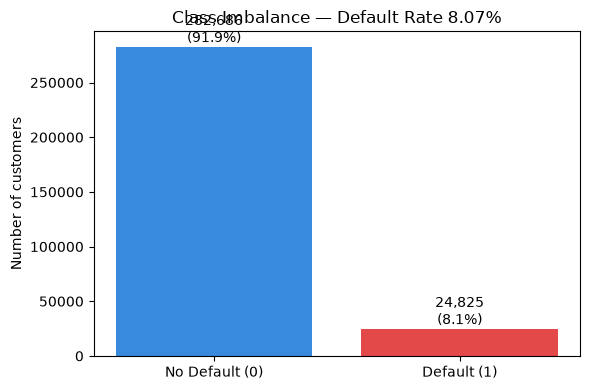

In [4]:
target_counts = app_train['TARGET'].value_counts()
default_rate = app_train['TARGET'].mean() * 100

print(target_counts)
print(f"\nDefault rate: {default_rate:.2f}%")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Default (0)', 'Default (1)'], target_counts.values,
              color=[C_BLUE, C_RED])
for b, v in zip(bars, target_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v/len(app_train)*100:.1f}%)",
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of customers')
ax.set_title(f'Class Imbalance — Default Rate {default_rate:.2f}%')
plt.tight_layout()
plt.savefig(FIG_PATH + "01_target_imbalance.png", dpi=150, bbox_inches='tight')
plt.show()

**Finding.** 8.07% default rate — a ~92/8 imbalance. Decision recorded for
Stage 6: handle via `class_weight` / `scale_pos_weight`, **not** SMOTE, and
evaluate with KS/AUC rather than accuracy.

## 1.2 Missing values — where and how much?

Columns with missing values: 67 of 122
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865        69.87
COMMONAREA_AVG                   214865        69.87
COMMONAREA_MODE                  214865        69.87
NONLIVINGAPARTMENTS_MEDI         213514        69.43
NONLIVINGAPARTMENTS_MODE         213514        69.43
NONLIVINGAPARTMENTS_AVG          213514        69.43
FONDKAPREMONT_MODE               210295        68.39
LIVINGAPARTMENTS_MODE            210199        68.35
LIVINGAPARTMENTS_MEDI            210199        68.35
LIVINGAPARTMENTS_AVG             210199        68.35
FLOORSMIN_MODE                   208642        67.85
FLOORSMIN_MEDI                   208642        67.85
FLOORSMIN_AVG                    208642        67.85
YEARS_BUILD_MODE                 204488        66.50
YEARS_BUILD_MEDI                 204488        66.50
YEARS_BUILD_AVG                  204488        66.50
OWN_CAR_AGE                      202929        65.99
LANDARE

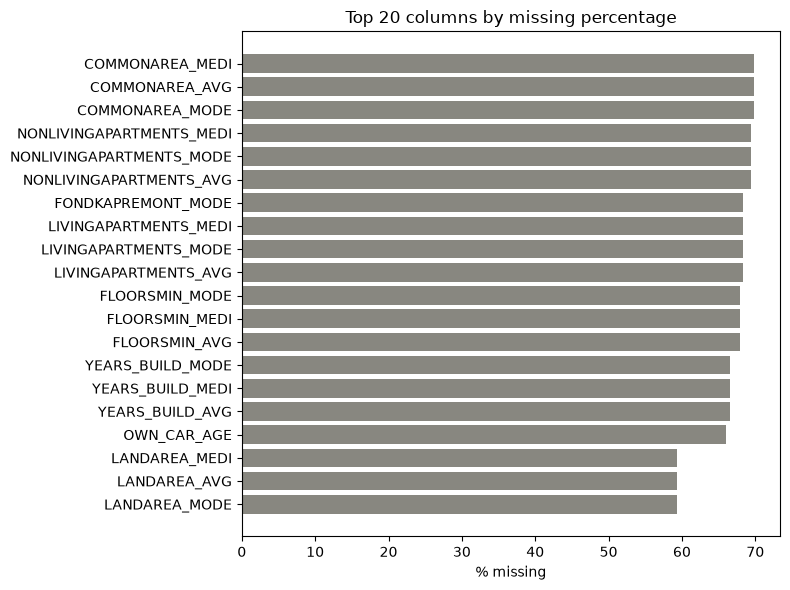

In [5]:
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train)) * 100

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)} of {app_train.shape[1]}")
print(missing_df.head(20))

top20 = missing_df.head(20).sort_values('missing_pct')
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index, top20['missing_pct'], color=C_GREY)
ax.set_xlabel('% missing')
ax.set_title('Top 20 columns by missing percentage')
plt.tight_layout()
plt.savefig(FIG_PATH + "01_missing_values_top20.png", dpi=150, bbox_inches='tight')
plt.show()

**Finding.** 67 columns have missing values. Most of the worst offenders
(48–70% missing) are building/property columns — handled as a group in
section 1.7 instead of imputing 40+ mostly-empty columns one by one.

## 1.3 `DAYS_EMPLOYED` — a sentinel error value

All `DAYS_*` columns count days **before** the application, so they should be
negative. Checking for suspicious positive values:

In [6]:
day_cols = [col for col in app_train.columns if 'DAYS' in col]
print(app_train[day_cols].describe().T[['min', 'max']])

                             min       max
DAYS_BIRTH             -25229.00  -7489.00
DAYS_EMPLOYED          -17912.00 365243.00
DAYS_REGISTRATION      -24672.00      0.00
DAYS_ID_PUBLISH         -7197.00      0.00
DAYS_LAST_PHONE_CHANGE  -4292.00      0.00


In [7]:
anomaly = (app_train['DAYS_EMPLOYED'] == 365243).sum()
print(f"Customers with DAYS_EMPLOYED = 365243 : {anomaly:,}")
print(f"Percentage                            : {anomaly/len(app_train)*100:.2f}%")

Customers with DAYS_EMPLOYED = 365243 : 55,374
Percentage                            : 18.01%


**Finding.** `DAYS_EMPLOYED` has a max of **+365,243 days (~1,000 years)** on
55,374 rows (18%). This is a sentinel code meaning *unemployed / pensioner*,
not a real employment duration.

**Fix — order matters:** create the anomaly flag **first** (unemployment is
itself a default-risk signal we want to keep), *then* replace the sentinel with
`NaN`. Doing it in the other order silently produces an all-zero flag — an
ordering bug caught and corrected during this project.

In [8]:
# Flag FIRST, replace SECOND — reversing these produces an all-zero flag
app_train['DAYS_EMPLOYED_ANOMALY'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)

print(f"Anomaly flag counts:\n{app_train['DAYS_EMPLOYED_ANOMALY'].value_counts()}")
print(f"\nDAYS_EMPLOYED after fix:\n{app_train['DAYS_EMPLOYED'].describe()}")

Anomaly flag counts:
DAYS_EMPLOYED_ANOMALY
0    252137
1     55374
Name: count, dtype: int64

DAYS_EMPLOYED after fix:
count   252137.00
mean     -2384.17
std       2338.36
min     -17912.00
25%      -3175.00
50%      -1648.00
75%       -767.00
max          0.00
Name: DAYS_EMPLOYED, dtype: float64


/var/folders/z9/x5z6vktj12l4vl2qpnpmhss40000gn/T/ipykernel_29831/4199791278.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['DAYS_EMPLOYED_ANOMALY'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)


## 1.4 Correlation with TARGET — first look at candidate features

A cheap, fast scan for which numeric columns carry signal, to focus the rest
of the EDA. (Correlation only captures linear signal — Stage 5 adds IV and
Mutual Information as stronger tests.)

Top 10 NEGATIVE correlations (lower value = higher risk):
EXT_SOURCE_3                 -0.18
EXT_SOURCE_2                 -0.16
EXT_SOURCE_1                 -0.16
DAYS_EMPLOYED_ANOMALY        -0.05
FLOORSMAX_AVG                -0.04
FLOORSMAX_MEDI               -0.04
FLOORSMAX_MODE               -0.04
AMT_GOODS_PRICE              -0.04
REGION_POPULATION_RELATIVE   -0.04
ELEVATORS_AVG                -0.03
Name: TARGET, dtype: float64

Top 10 POSITIVE correlations (higher value = higher risk):
FLAG_DOCUMENT_3               0.04
REG_CITY_NOT_LIVE_CITY        0.04
FLAG_EMP_PHONE                0.05
REG_CITY_NOT_WORK_CITY        0.05
DAYS_ID_PUBLISH               0.05
DAYS_LAST_PHONE_CHANGE        0.06
REGION_RATING_CLIENT          0.06
REGION_RATING_CLIENT_W_CITY   0.06
DAYS_EMPLOYED                 0.07
DAYS_BIRTH                    0.08
Name: TARGET, dtype: float64


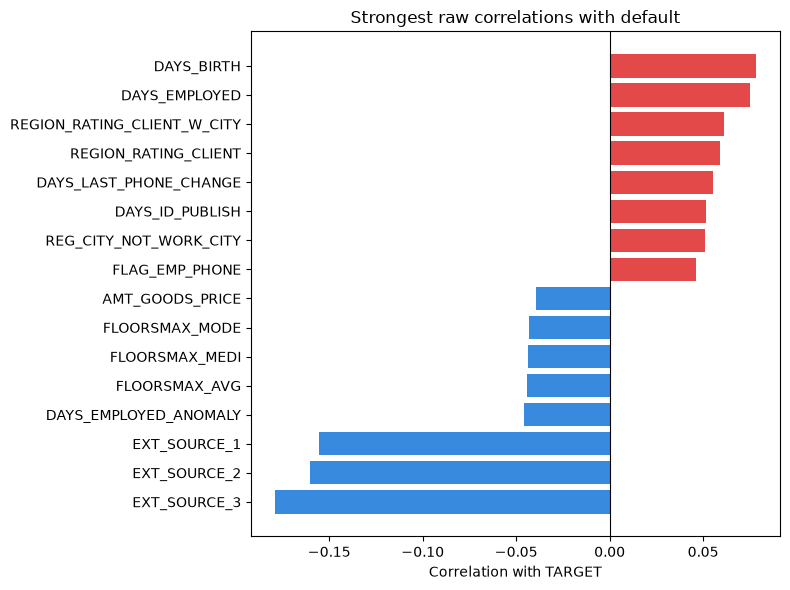

In [9]:
correlations = app_train.corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values()

print("Top 10 NEGATIVE correlations (lower value = higher risk):")
print(correlations.head(10))
print("\nTop 10 POSITIVE correlations (higher value = higher risk):")
print(correlations.tail(10))

top_corr = pd.concat([correlations.head(8), correlations.tail(8)]).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = [C_BLUE if v < 0 else C_RED for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Strongest raw correlations with default')
plt.tight_layout()
plt.savefig(FIG_PATH + "01_target_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

**Key finding.** `EXT_SOURCE_1/2/3` (external credit-bureau-style scores) are
the strongest individual predictors (−0.16 to −0.18). Our engineered
`DAYS_EMPLOYED_ANOMALY` flag already shows real signal, validating the fix.
`DAYS_BIRTH` (age) also matters — younger customers default more.

## 1.5 EXT_SOURCE deep-dive — validate the top predictors

In [10]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print("Missing %:")
print((app_train[ext_cols].isnull().sum() / len(app_train) * 100).round(2))

print("\nMean score by TARGET group:")
for col in ext_cols:
    print(f"\n{col}")
    print(app_train.groupby('TARGET')[col].mean())

Missing %:
EXT_SOURCE_1   56.38
EXT_SOURCE_2    0.21
EXT_SOURCE_3   19.83
dtype: float64

Mean score by TARGET group:

EXT_SOURCE_1
TARGET
0   0.51
1   0.39
Name: EXT_SOURCE_1, dtype: float64

EXT_SOURCE_2
TARGET
0   0.52
1   0.41
Name: EXT_SOURCE_2, dtype: float64

EXT_SOURCE_3
TARGET
0   0.52
1   0.39
Name: EXT_SOURCE_3, dtype: float64


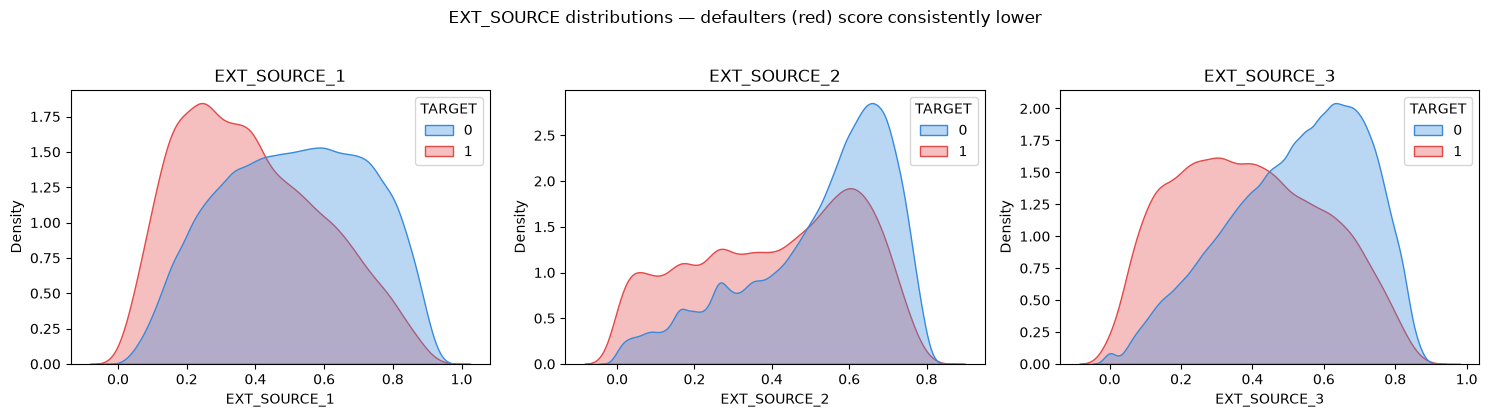

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ext_cols):
    sns.kdeplot(data=app_train, x=col, hue='TARGET', common_norm=False,
                fill=True, alpha=0.35, palette=[C_BLUE, C_RED], ax=ax)
    ax.set_title(col)
fig.suptitle('EXT_SOURCE distributions — defaulters (red) score consistently lower', y=1.03)
plt.tight_layout()
plt.savefig(FIG_PATH + "01_ext_source_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

**Key finding — EXT_SOURCE validated.** Defaulters score ~0.11–0.13 lower on
all three scores, with clearly shifted distributions — genuine signal, not a
spurious correlation. `EXT_SOURCE_1` is 56% missing, so imputation must be
handled carefully (Stage 6); combining the three scores is an obvious Stage 4
feature-engineering candidate.

## 1.6 Financial amount columns — outliers

Financial data is naturally right-skewed. The test used throughout this
project to separate *natural skew* from *data-entry errors* is the
**gap ratio** = max / 99th percentile.

In [12]:
core_amt = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
print(app_train[core_amt].describe())

print("\nGap ratios (max / 99th percentile):")
for col in core_amt:
    p99 = app_train[col].quantile(0.99)
    max_val = app_train[col].max()
    print(f"{col:20s} 99th: {p99:>12,.0f}   max: {max_val:>14,.0f}   gap ratio: {max_val/p99:6.1f}x")

       AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE
count         307511.00   307511.00    307499.00        307233.00
mean          168797.92   599026.00     27108.57        538396.21
std           237123.15   402490.78     14493.74        369446.46
min            25650.00    45000.00      1615.50         40500.00
25%           112500.00   270000.00     16524.00        238500.00
50%           147150.00   513531.00     24903.00        450000.00
75%           202500.00   808650.00     34596.00        679500.00
max        117000000.00  4050000.00    258025.50       4050000.00

Gap ratios (max / 99th percentile):
AMT_INCOME_TOTAL     99th:      472,500   max:    117,000,000   gap ratio:  247.6x
AMT_CREDIT           99th:    1,854,000   max:      4,050,000   gap ratio:    2.2x
AMT_ANNUITY          99th:       70,006   max:        258,026   gap ratio:    3.7x
AMT_GOODS_PRICE      99th:    1,800,000   max:      4,050,000   gap ratio:    2.2x


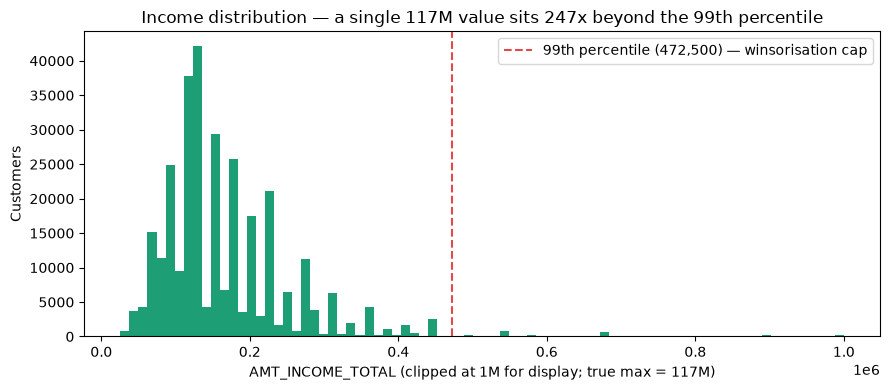

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(app_train['AMT_INCOME_TOTAL'].clip(upper=1_000_000), bins=80, color=C_GREEN)
ax.axvline(472500, color=C_RED, linestyle='--',
           label='99th percentile (472,500) — winsorisation cap')
ax.set_xlabel('AMT_INCOME_TOTAL (clipped at 1M for display; true max = 117M)')
ax.set_ylabel('Customers')
ax.set_title('Income distribution — a single 117M value sits 247x beyond the 99th percentile')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH + "01_income_outlier.png", dpi=150, bbox_inches='tight')
plt.show()

**Decision.** `AMT_INCOME_TOTAL`'s gap ratio is **247x** (max 117M vs 99th pct
472.5k) — a data-entry error, not a billionaire. The other three AMT columns
show 2.2–3.7x, consistent with natural skew: no treatment needed.

Fix for income: **winsorise at the 99th percentile** (cap, don't delete rows)
and keep a flag, since being an outlier may itself be signal (fraud/unusual profile).

In [14]:
# Flag rows that get capped — the outlier itself may be signal
app_train['INCOME_OUTLIER_FLAG'] = (app_train['AMT_INCOME_TOTAL'] > 472500).astype(int)

cap_value = app_train['AMT_INCOME_TOTAL'].quantile(0.99)
app_train['AMT_INCOME_TOTAL_CAPPED'] = app_train['AMT_INCOME_TOTAL'].clip(upper=cap_value)

print(f"Outlier flag counts:\n{app_train['INCOME_OUTLIER_FLAG'].value_counts()}")
print(f"\nBefore capping - max: {app_train['AMT_INCOME_TOTAL'].max():,.0f}")
print(f"After capping  - max: {app_train['AMT_INCOME_TOTAL_CAPPED'].max():,.0f}")

Outlier flag counts:
INCOME_OUTLIER_FLAG
0    304497
1      3014
Name: count, dtype: int64

Before capping - max: 117,000,000
After capping  - max: 472,500


/var/folders/z9/x5z6vktj12l4vl2qpnpmhss40000gn/T/ipykernel_29831/3927561421.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['INCOME_OUTLIER_FLAG'] = (app_train['AMT_INCOME_TOTAL'] > 472500).astype(int)
/var/folders/z9/x5z6vktj12l4vl2qpnpmhss40000gn/T/ipykernel_29831/3927561421.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['AMT_INCOME_TOTAL_CAPPED'] = app_train['AMT_INCOME_TOTAL'].clip(upper=cap_value)


In [15]:
# AMT_ANNUITY / AMT_GOODS_PRICE missing check
print(app_train[['AMT_ANNUITY', 'AMT_GOODS_PRICE']].isnull().sum())

AMT_ANNUITY         12
AMT_GOODS_PRICE    278
dtype: int64


**Decision.** Both <0.1% missing — median imputation in the Stage 6 pipeline
(median over mean because of right-skew). Too rare to justify indicator flags.

## 1.7 Categorical columns — cardinality, missingness, and the building-column group

In [16]:
cat_cols = app_train.select_dtypes(include='object').columns.tolist()
print(f"Number of categorical columns: {len(cat_cols)}\n")

for col in cat_cols:
    n_unique = app_train[col].nunique()
    missing_pct = app_train[col].isnull().sum() / len(app_train) * 100
    print(f"{col:30s} unique: {n_unique:3d}   missing: {missing_pct:5.1f}%")

/var/folders/z9/x5z6vktj12l4vl2qpnpmhss40000gn/T/ipykernel_29831/723455072.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = app_train.select_dtypes(include='object').columns.tolist()


Number of categorical columns: 16

NAME_CONTRACT_TYPE             unique:   2   missing:   0.0%
CODE_GENDER                    unique:   3   missing:   0.0%
FLAG_OWN_CAR                   unique:   2   missing:   0.0%
FLAG_OWN_REALTY                unique:   2   missing:   0.0%
NAME_TYPE_SUITE                unique:   7   missing:   0.4%
NAME_INCOME_TYPE               unique:   8   missing:   0.0%
NAME_EDUCATION_TYPE            unique:   5   missing:   0.0%
NAME_FAMILY_STATUS             unique:   6   missing:   0.0%
NAME_HOUSING_TYPE              unique:   6   missing:   0.0%
OCCUPATION_TYPE                unique:  18   missing:  31.3%
WEEKDAY_APPR_PROCESS_START     unique:   7   missing:   0.0%
ORGANIZATION_TYPE              unique:  58   missing:   0.0%
FONDKAPREMONT_MODE             unique:   4   missing:  68.4%
HOUSETYPE_MODE                 unique:   3   missing:  50.2%
WALLSMATERIAL_MODE             unique:   7   missing:  50.8%
EMERGENCYSTATE_MODE            unique:   2   missi

In [17]:
# Is OCCUPATION_TYPE's 31% missingness random, or informative?
print(app_train.groupby(app_train['OCCUPATION_TYPE'].isnull())['DAYS_EMPLOYED_ANOMALY'].mean())

OCCUPATION_TYPE
False   0.00
True    0.57
Name: DAYS_EMPLOYED_ANOMALY, dtype: float64


**Key finding.** 57% of rows with missing `OCCUPATION_TYPE` are flagged
unemployed, vs 0% of non-missing rows — the missingness is **informative,
not random**. Decision: encode missing as its own `"Unknown"` category rather
than imputing with the mode, preserving the signal.

In [18]:
building_cats = ['FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

for col in building_cats:
    print(f"\n{col} — default rate by missing status:")
    print(app_train.groupby(app_train[col].isnull())['TARGET'].mean())


FONDKAPREMONT_MODE — default rate by missing status:
FONDKAPREMONT_MODE
False   0.07
True    0.09
Name: TARGET, dtype: float64

HOUSETYPE_MODE — default rate by missing status:
HOUSETYPE_MODE
False   0.07
True    0.09
Name: TARGET, dtype: float64

WALLSMATERIAL_MODE — default rate by missing status:
WALLSMATERIAL_MODE
False   0.07
True    0.09
Name: TARGET, dtype: float64

EMERGENCYSTATE_MODE — default rate by missing status:
EMERGENCYSTATE_MODE
False   0.07
True    0.09
Name: TARGET, dtype: float64


**Finding.** All four building categoricals show the same pattern: defaulters
missing at ~9% vs ~7% — the *missing pattern itself* is the signal, likely tied
to property-ownership status. Decision: replace all four with a single
`HAS_BUILDING_INFO` flag instead of imputing each separately.

In [19]:
app_train['HAS_BUILDING_INFO'] = app_train[building_cats].notnull().all(axis=1).astype(int)
print(app_train['HAS_BUILDING_INFO'].value_counts())
print(app_train.groupby('HAS_BUILDING_INFO')['TARGET'].mean())

app_train = app_train.drop(columns=building_cats, errors='ignore')
print(f"\nShape after dropping the 4 building categoricals: {app_train.shape}")

HAS_BUILDING_INFO
0    211088
1     96423
Name: count, dtype: int64
HAS_BUILDING_INFO
0   0.09
1   0.07
Name: TARGET, dtype: float64

Shape after dropping the 4 building categoricals: (307511, 122)


/var/folders/z9/x5z6vktj12l4vl2qpnpmhss40000gn/T/ipykernel_29831/1141109799.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['HAS_BUILDING_INFO'] = app_train[building_cats].notnull().all(axis=1).astype(int)


In [20]:
print(app_train['NAME_HOUSING_TYPE'].value_counts())
print()
print(app_train.groupby('NAME_HOUSING_TYPE')['TARGET'].mean().sort_values(ascending=False))

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

NAME_HOUSING_TYPE
Rented apartment      0.12
With parents          0.12
Municipal apartment   0.09
Co-op apartment       0.08
House / apartment     0.08
Office apartment      0.07
Name: TARGET, dtype: float64


In [21]:
for col in ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']:
    print(f"\n{col}")
    print(app_train.groupby(col)['TARGET'].mean().sort_values(ascending=False))
    print(f"\nCounts:\n{app_train[col].value_counts()}")


NAME_INCOME_TYPE
NAME_INCOME_TYPE
Maternity leave        0.40
Unemployed             0.36
Working                0.10
Commercial associate   0.07
State servant          0.06
Pensioner              0.05
Businessman            0.00
Student                0.00
Name: TARGET, dtype: float64

Counts:
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Lower secondary                 0.11
Secondary / secondary special   0.09
Incomplete higher               0.08
Higher education                0.05
Academic degree                 0.02
Name: TARGET, dtype: float64

Counts:
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower se

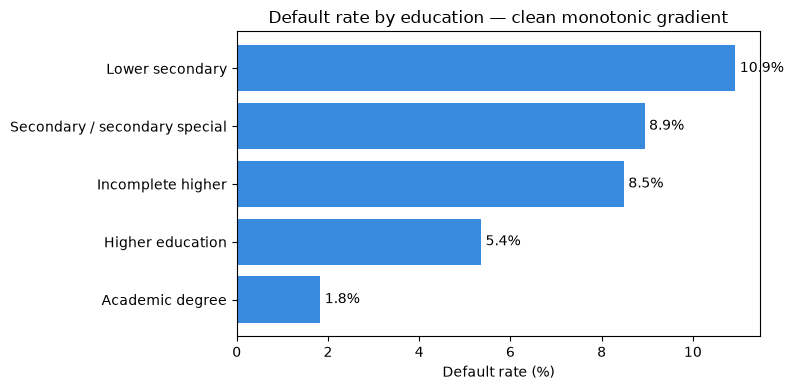

In [22]:
edu = (app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(edu.index, edu.values, color=C_BLUE)
for i, v in enumerate(edu.values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va='center', fontsize=10)
ax.set_xlabel('Default rate (%)')
ax.set_title('Default rate by education — clean monotonic gradient')
plt.tight_layout()
plt.savefig(FIG_PATH + "01_default_by_education.png", dpi=150, bbox_inches='tight')
plt.show()

**Key finding.** `NAME_EDUCATION_TYPE`: clean monotonic gradient (~2% to ~11%)
with reliable sample sizes in all 5 categories — a strong feature.
`NAME_INCOME_TYPE`: the extreme rates (0%, 36%, 40%) come from categories with
under 25 people — not statistically reliable; the 4 major categories show a
believable 5–10% range.

## 1.8 FLAG columns — drop the noise

In [23]:
flag_cols = [col for col in app_train.columns if col.startswith('FLAG_')]
numeric_flags = [col for col in flag_cols if col not in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']]

print(f"Number of FLAG columns: {len(flag_cols)}\n")
for col in numeric_flags:
    corr = app_train[col].corr(app_train['TARGET'])
    pct_1 = app_train[col].mean() * 100
    print(f"{col:25s} corr: {corr:7.3f}   %=1: {pct_1:5.1f}%")

Number of FLAG columns: 28

FLAG_MOBIL                corr:   0.001   %=1: 100.0%
FLAG_EMP_PHONE            corr:   0.046   %=1:  82.0%
FLAG_WORK_PHONE           corr:   0.029   %=1:  19.9%
FLAG_CONT_MOBILE          corr:   0.000   %=1:  99.8%
FLAG_PHONE                corr:  -0.024   %=1:  28.1%
FLAG_EMAIL                corr:  -0.002   %=1:   5.7%
FLAG_DOCUMENT_2           corr:   0.005   %=1:   0.0%
FLAG_DOCUMENT_3           corr:   0.044   %=1:  71.0%
FLAG_DOCUMENT_4           corr:  -0.003   %=1:   0.0%
FLAG_DOCUMENT_5           corr:  -0.000   %=1:   1.5%
FLAG_DOCUMENT_6           corr:  -0.029   %=1:   8.8%
FLAG_DOCUMENT_7           corr:  -0.002   %=1:   0.0%
FLAG_DOCUMENT_8           corr:  -0.008   %=1:   8.1%
FLAG_DOCUMENT_9           corr:  -0.004   %=1:   0.4%
FLAG_DOCUMENT_10          corr:  -0.001   %=1:   0.0%
FLAG_DOCUMENT_11          corr:  -0.004   %=1:   0.4%
FLAG_DOCUMENT_12          corr:  -0.001   %=1:   0.0%
FLAG_DOCUMENT_13          corr:  -0.012   %=1:   0.4%


**Decision.** `FLAG_MOBIL` (100% = 1) and `FLAG_CONT_MOBILE` (99.8% = 1) are
near-constant — no information, drop. Most `FLAG_DOCUMENT_X` columns combine
near-zero correlation (<0.01) with extreme imbalance — noise, drop. **Keep**
`FLAG_DOCUMENT_3`, `FLAG_EMP_PHONE`, `FLAG_WORK_PHONE`, `FLAG_PHONE`, which show
mild but real correlation (0.024–0.046) with reasonable balance.

In [24]:
drop_flags = ['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4',
              'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
              'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
              'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
              'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']

app_train = app_train.drop(columns=drop_flags, errors='ignore')
print(f"Shape after dropping low-signal flags: {app_train.shape}")

Shape after dropping low-signal flags: (307511, 102)


In [25]:
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    print(f"\n{col}")
    print(app_train.groupby(col)['TARGET'].mean())


FLAG_OWN_CAR
FLAG_OWN_CAR
N   0.09
Y   0.07
Name: TARGET, dtype: float64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
N   0.08
Y   0.08
Name: TARGET, dtype: float64


**Decision.** `FLAG_OWN_CAR`: small but consistent gap (9% vs 7%) — car
ownership weakly signals stability, keep (converted to 0/1).
`FLAG_OWN_REALTY`: identical default rate either way — drop.

In [26]:
app_train = app_train.drop(columns=['FLAG_OWN_REALTY'], errors='ignore')
app_train['FLAG_OWN_CAR'] = (app_train['FLAG_OWN_CAR'] == 'Y').astype(int)

print(f"Shape: {app_train.shape}")
print(app_train['FLAG_OWN_CAR'].value_counts())

Shape: (307511, 101)
FLAG_OWN_CAR
0    202924
1    104587
Name: count, dtype: int64


## 1.9 `ORGANIZATION_TYPE` — 58 categories is too many

Too many categories for clean one-hot encoding. Testing several minimum-count
thresholds for grouping rare categories into `"Other"`:

In [27]:
org_counts = app_train['ORGANIZATION_TYPE'].value_counts()

for threshold in [500, 1000, 2000, 5000]:
    n_remaining = (org_counts >= threshold).sum()
    print(f"Threshold {threshold:5d} -> {n_remaining} categories remain (rest grouped as 'Other')")

Threshold   500 -> 41 categories remain (rest grouped as 'Other')
Threshold  1000 -> 33 categories remain (rest grouped as 'Other')
Threshold  2000 -> 25 categories remain (rest grouped as 'Other')
Threshold  5000 -> 13 categories remain (rest grouped as 'Other')


**Decision.** Threshold **2000** → 58 categories become 25: enough reduction to
kill the noise from tiny categories, while keeping meaningful distinctions
(Construction, Self-employed, Military…) with statistically reliable sample sizes.

In [28]:
rare_orgs = org_counts[org_counts < 2000].index.tolist()
app_train['ORGANIZATION_TYPE'] = app_train['ORGANIZATION_TYPE'].replace(rare_orgs, 'Other')

print(f"Categories grouped into 'Other': {len(rare_orgs)}")
print(f"Final category count: {app_train['ORGANIZATION_TYPE'].nunique()}")

Categories grouped into 'Other': 33
Final category count: 25


## 1.10 `CNT_CHILDREN` — cap extreme values

In [29]:
print(app_train['CNT_CHILDREN'].value_counts().sort_index(ascending=False).head(10))

CNT_CHILDREN
19     2
14     3
12     2
11     1
10     2
9      2
8      2
7      7
6     21
5     84
Name: count, dtype: int64


**Decision.** Values above 5 children have 1–7 people each — likely data-entry
anomalies. Cap at 5 to avoid noisy tree splits.

In [30]:
app_train['CNT_CHILDREN'] = app_train['CNT_CHILDREN'].clip(upper=5)
print(app_train['CNT_CHILDREN'].value_counts().sort_index())

CNT_CHILDREN
0    215371
1     61119
2     26749
3      3717
4       429
5       126
Name: count, dtype: int64


## 1.11 Drop sparse building *numeric* columns & final missing audit

The 44 numeric building columns (AVG/MODE/MEDI triplets) share the same
48–70% missingness as the categorical building columns already replaced by
`HAS_BUILDING_INFO` in 1.7 — same decision applies.

In [31]:
drop_building_numeric = [
    'COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI',
    'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI',
    'FLOORSMIN_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI',
    'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI',
    'LANDAREA_AVG', 'LANDAREA_MODE', 'LANDAREA_MEDI',
    'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI',
    'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_MEDI',
    'ELEVATORS_AVG', 'ELEVATORS_MODE', 'ELEVATORS_MEDI',
    'APARTMENTS_AVG', 'APARTMENTS_MODE', 'APARTMENTS_MEDI',
    'ENTRANCES_AVG', 'ENTRANCES_MODE', 'ENTRANCES_MEDI',
    'LIVINGAREA_AVG', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI',
    'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'FLOORSMAX_MEDI',
    'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI',
    'TOTALAREA_MODE'
]

app_train = app_train.drop(columns=drop_building_numeric, errors='ignore')
print(f"Shape after dropping building numeric columns: {app_train.shape}")

Shape after dropping building numeric columns: (307511, 58)


In [32]:
remaining_missing = app_train.isnull().sum()
remaining_missing_pct = (remaining_missing / len(app_train)) * 100

missing_full = pd.DataFrame({'missing_count': remaining_missing,
                             'missing_pct': remaining_missing_pct})
missing_full = missing_full[missing_full['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(f"Columns still with missing values: {len(missing_full)}")
print(missing_full)

Columns still with missing values: 21
                            missing_count  missing_pct
OWN_CAR_AGE                        202929        65.99
EXT_SOURCE_1                       173378        56.38
OCCUPATION_TYPE                     96391        31.35
EXT_SOURCE_3                        60965        19.83
DAYS_EMPLOYED                       55374        18.01
AMT_REQ_CREDIT_BUREAU_YEAR          41519        13.50
AMT_REQ_CREDIT_BUREAU_QRT           41519        13.50
AMT_REQ_CREDIT_BUREAU_MON           41519        13.50
AMT_REQ_CREDIT_BUREAU_WEEK          41519        13.50
AMT_REQ_CREDIT_BUREAU_DAY           41519        13.50
AMT_REQ_CREDIT_BUREAU_HOUR          41519        13.50
NAME_TYPE_SUITE                      1292         0.42
DEF_60_CNT_SOCIAL_CIRCLE             1021         0.33
OBS_30_CNT_SOCIAL_CIRCLE             1021         0.33
OBS_60_CNT_SOCIAL_CIRCLE             1021         0.33
DEF_30_CNT_SOCIAL_CIRCLE             1021         0.33
EXT_SOURCE_2               

**Remaining missingness is deliberate.** `EXT_SOURCE_*`, `OCCUPATION_TYPE`,
`OWN_CAR_AGE`, `AMT_REQ_CREDIT_BUREAU_*` etc. are left as-is: their imputation
belongs to the Stage 6 **model-specific pipelines**, fit on training data only,
to avoid leakage. (`OWN_CAR_AGE` is missing exactly for customers with no car —
structural, not random.)

## 1.12 Save checkpoint

In [33]:
app_train.to_csv(DATA_PATH + "app_train_cleaned.csv", index=False)
print("Checkpoint saved: app_train_cleaned.csv")
print(f"Final shape: {app_train.shape}")

Checkpoint saved: app_train_cleaned.csv
Final shape: (307511, 58)


---
> **Note on everything below.** From here on, the notebook explores the six
> **child tables**. To test each discovered signal against `TARGET`, flags are
> merged onto a working copy called **`chk`** — never onto the saved checkpoint.
> These merges are **exploratory only**: the production versions of these
> features are rebuilt properly (and re-verified) in the SQL pipeline
> (notebook 02). This separation is what makes the notebook safe to re-run
> without polluting the checkpoint.

> **Abandoned plan (recorded honestly):** an earlier version of this notebook
> computed a time-based train/test split boundary from `DAYS_DECISION`. That
> plan was dropped after finding `DAYS_DECISION` only exists in
> `previous_application` (past loans), not at the application level — full
> reasoning in notebook 05. The dead-end cells were removed from this notebook.

In [34]:
# Working copy for exploratory target-vs-flag checks (NOT saved anywhere)
chk = app_train.copy()
print(f"Exploration copy created: {chk.shape}")

Exploration copy created: (307511, 58)


<a id="2"></a>
# 2. `bureau.csv` — credit history at other banks

One row per **external loan** — a child table needing per-customer aggregation
later. The question here: which behaviours at *other* banks predict default at
Home Credit?

In [35]:
bureau = pd.read_csv(DATA_PATH + "bureau.csv")

print(f"Shape: {bureau.shape}")
print(f"Unique customers (SK_ID_CURR): {bureau['SK_ID_CURR'].nunique():,}")
print(f"Avg bureau records per customer: {bureau.shape[0] / bureau['SK_ID_CURR'].nunique():.2f}")
bureau.head()

Shape: (1716428, 17)
Unique customers (SK_ID_CURR): 305,811
Avg bureau records per customer: 5.61


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,NaN,0,91323.00,0.00,NaN,0.00,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.00,NaN,NaN,0,225000.00,171342.00,NaN,0.00,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00,NaN,NaN,0,464323.50,NaN,NaN,0.00,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.00,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.00,NaN,77674.50,0,2700000.00,NaN,NaN,0.00,Consumer credit,-21,NaN


In [36]:
# Coverage: which app_train customers have NO external history at all?
bureau_customers = set(bureau['SK_ID_CURR'])
chk['HAS_BUREAU_HISTORY'] = chk['SK_ID_CURR'].isin(bureau_customers).astype(int)

print(f"Customers with no bureau history: {(chk['HAS_BUREAU_HISTORY'] == 0).sum():,}")
print(chk.groupby('HAS_BUREAU_HISTORY')['TARGET'].mean())

Customers with no bureau history: 44,020
HAS_BUREAU_HISTORY
0   0.10
1   0.08
Name: TARGET, dtype: float64


**Finding — `HAS_BUREAU_HISTORY`.** 44,020 customers (14.3%) have no external
records; they default slightly more (10% vs 8%) — thin-file / first-time
borrowers. Weak but real signal, keep as a candidate.

In [37]:
print(bureau['CREDIT_ACTIVE'].value_counts())

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


In [38]:
# "Bad debt" at another bank — rare (21 records) but the most severe status
bad_debt_customers = bureau[bureau['CREDIT_ACTIVE'] == 'Bad debt']['SK_ID_CURR'].unique()
chk['HAS_BAD_DEBT'] = chk['SK_ID_CURR'].isin(bad_debt_customers).astype(int)

print(chk['HAS_BAD_DEBT'].value_counts())
print(chk.groupby('HAS_BAD_DEBT')['TARGET'].mean())

HAS_BAD_DEBT
0    307491
1        20
Name: count, dtype: int64
HAS_BAD_DEBT
0   0.08
1   0.20
Name: TARGET, dtype: float64


**Finding — `HAS_BAD_DEBT`.** Only 20 customers, defaulting at 20% vs 8%.
Sample far too small for statistical confidence, but direction is
business-logical. Keep as a low-cost feature; trees will down-weight it if
it doesn't generalise.

### Cleaning `bureau` amount columns

In [39]:
# Negative debt = overpayment adjustments -> clip to 0
negative_debt = (bureau['AMT_CREDIT_SUM_DEBT'] < 0).sum()
print(f"Records with negative debt: {negative_debt}")
bureau['AMT_CREDIT_SUM_DEBT'] = bureau['AMT_CREDIT_SUM_DEBT'].clip(lower=0)

# Same gap-ratio outlier test as app_train, then winsorise at 99th pct
for col in ['AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM']:
    p999 = bureau[col].quantile(0.999)
    max_val = bureau[col].max()
    print(f"{col:22s} 99.9th: {p999:>14,.0f}   max: {max_val:>14,.0f}   gap: {max_val/p999:5.1f}x")

for col in ['AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM']:
    cap_value = bureau[col].quantile(0.99)
    bureau[col] = bureau[col].clip(upper=cap_value)
    print(f"{col} capped at 99th pct ({cap_value:,.0f})")

Records with negative debt: 8418
AMT_CREDIT_SUM_DEBT    99.9th:      8,841,942   max:    170,100,000   gap:  19.2x
AMT_CREDIT_SUM         99.9th:     11,021,004   max:    585,000,000   gap:  53.1x
AMT_CREDIT_SUM_DEBT capped at 99th pct (2,259,728)
AMT_CREDIT_SUM capped at 99th pct (3,700,916)


In [40]:
print(bureau['CREDIT_DAY_OVERDUE'].describe())
print(f"\nRecords with any overdue (>0 days): {(bureau['CREDIT_DAY_OVERDUE'] > 0).sum()} "
      f"({(bureau['CREDIT_DAY_OVERDUE'] > 0).mean()*100:.2f}%)")

count   1716428.00
mean          0.82
std          36.54
min           0.00
25%           0.00
50%           0.00
75%           0.00
max        2792.00
Name: CREDIT_DAY_OVERDUE, dtype: float64

Records with any overdue (>0 days): 4217 (0.25%)


In [41]:
overdue_customers = bureau[bureau['CREDIT_DAY_OVERDUE'] > 0]['SK_ID_CURR'].unique()
chk['HAS_OVERDUE_HISTORY'] = chk['SK_ID_CURR'].isin(overdue_customers).astype(int)

print(chk['HAS_OVERDUE_HISTORY'].value_counts())
print(chk.groupby('HAS_OVERDUE_HISTORY')['TARGET'].mean())

HAS_OVERDUE_HISTORY
0    304114
1      3397
Name: count, dtype: int64
HAS_OVERDUE_HISTORY
0   0.08
1   0.16
Name: TARGET, dtype: float64


**Key finding — `HAS_OVERDUE_HISTORY`.** Customers with any overdue external
credit default at **exactly 2x the rate (16% vs 8%)**, with a solid sample
(3,397 customers). Clear business logic + solid statistics = one of the most
trustworthy features in the whole project.

**Aggregation rule discovered:** overdue is a *rare, abnormal event* (0.25% of
records) → aggregate with **MAX** per customer in the SQL pipeline, not MEAN.

In [42]:
bureau.to_csv(DATA_PATH + "bureau_cleaned.csv", index=False)
print(f"Checkpoint saved: bureau_cleaned.csv  {bureau.shape}")

Checkpoint saved: bureau_cleaned.csv  (1716428, 17)


<a id="3"></a>
# 3. `bureau_balance.csv` — monthly bureau statuses

The **largest** table (27.3M rows), and a *grandchild*: one bureau loan → many
monthly rows, linked back to customers via `bureau.csv`. Question: is the extra
monthly detail worth its size?

In [43]:
bureau_balance = pd.read_csv(DATA_PATH + "bureau_balance.csv")

print(f"Shape: {bureau_balance.shape}")
print(f"Unique SK_ID_BUREAU: {bureau_balance['SK_ID_BUREAU'].nunique():,}")
print()
print(bureau_balance['STATUS'].value_counts())

Shape: (27299925, 3)
Unique SK_ID_BUREAU: 817,395

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64


Status codes: `C`=closed, `0`=no overdue, `X`=unknown, `1`–`5`=increasing
overdue severity (5 = 120+ days / write-off). Testing the most severe status:

In [44]:
severe_overdue_loans = bureau_balance[bureau_balance['STATUS'] == '5']['SK_ID_BUREAU'].unique()
severe_customers = bureau[bureau['SK_ID_BUREAU'].isin(severe_overdue_loans)]['SK_ID_CURR'].unique()

chk['HAS_SEVERE_OVERDUE'] = chk['SK_ID_CURR'].isin(severe_customers).astype(int)
print(chk['HAS_SEVERE_OVERDUE'].value_counts())
print(chk.groupby('HAS_SEVERE_OVERDUE')['TARGET'].mean())

HAS_SEVERE_OVERDUE
0    305305
1      2206
Name: count, dtype: int64
HAS_SEVERE_OVERDUE
0   0.08
1   0.11
Name: TARGET, dtype: float64


**Decision — deprioritise this table.** 27.3M rows buy only a ~3pp default-rate
gap (`HAS_SEVERE_OVERDUE`), vs `bureau.csv`'s 8pp gap from a table 16x smaller.
Cost/benefit says: exclude `bureau_balance` from the SQL pipeline; revisit only
if model performance later demands it. *(Honest gap, recorded: the lightweight
`HAS_SEVERE_OVERDUE` flag was also not carried into the final pipeline.)*

The memory it occupies is not worth keeping around:

In [45]:
del bureau_balance
gc.collect()
print("bureau_balance released from memory.")

bureau_balance released from memory.


<a id="4"></a>
# 4. `previous_application.csv` — past Home Credit applications

Same lender, past applications. Does Home Credit's *own* history with a
customer predict their future risk?

In [46]:
prev_app = pd.read_csv(DATA_PATH + "previous_application.csv")

print(f"Shape: {prev_app.shape}")
print(f"Unique SK_ID_CURR: {prev_app['SK_ID_CURR'].nunique():,}")
print(f"Avg previous applications per customer: {prev_app.shape[0] / prev_app['SK_ID_CURR'].nunique():.2f}")

Shape: (1670214, 37)
Unique SK_ID_CURR: 338,857
Avg previous applications per customer: 4.93


**Note on coverage.** 338,857 unique customers — *more* than app_train's
307,511, because this table also covers `application_test` customers. Expected,
not an error.

In [47]:
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [48]:
refused_customers = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Refused']['SK_ID_CURR'].unique()
chk['HAS_PRIOR_REFUSAL'] = chk['SK_ID_CURR'].isin(refused_customers).astype(int)

print(chk['HAS_PRIOR_REFUSAL'].value_counts())
print(chk.groupby('HAS_PRIOR_REFUSAL')['TARGET'].mean())

HAS_PRIOR_REFUSAL
0    207217
1    100294
Name: count, dtype: int64
HAS_PRIOR_REFUSAL
0   0.07
1   0.10
Name: TARGET, dtype: float64


**Key finding — `HAS_PRIOR_REFUSAL`.** 100,294 customers (32.6%) were refused
at least once before; they default at 10% vs 7%. Large sample, reliable signal:
the lender's own past decisions carry predictive value.

### Outlier & missingness checks

In [49]:
print("Gap ratios (max / 99th percentile) — natural skew vs data error test:")
for col in ['AMT_APPLICATION', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    p99 = prev_app[col].quantile(0.99)
    max_val = prev_app[col].max()
    print(f"{col:20s} 99th: {p99:>12,.0f}   max: {max_val:>14,.0f}   gap ratio: {max_val/p99:5.1f}x")

Gap ratios (max / 99th percentile) — natural skew vs data error test:
AMT_APPLICATION      99th:    1,350,000   max:      6,905,160   gap ratio:   5.1x
AMT_CREDIT           99th:    1,515,378   max:      6,905,160   gap ratio:   4.6x
AMT_ANNUITY          99th:       69,686   max:        418,058   gap ratio:   6.0x
AMT_GOODS_PRICE      99th:    1,395,000   max:      6,905,160   gap ratio:   4.9x


Gap ratios 4.6–6.0x — natural right-skew, **no capping needed** (matches the
app_train AMT pattern).

In [50]:
print("Missing % overall:")
print((prev_app[['AMT_ANNUITY', 'AMT_GOODS_PRICE']].isnull().sum() / len(prev_app) * 100).round(2))

print("\nAMT_ANNUITY missing rate by contract status:")
print(prev_app.groupby('NAME_CONTRACT_STATUS')['AMT_ANNUITY'].apply(lambda x: x.isnull().mean()))

Missing % overall:
AMT_ANNUITY       22.29
AMT_GOODS_PRICE   23.08
dtype: float64

AMT_ANNUITY missing rate by contract status:
NAME_CONTRACT_STATUS
Approved       0.00
Canceled       0.97
Refused        0.14
Unused offer   0.97
Name: AMT_ANNUITY, dtype: float64


**Key finding — structural missingness.** Approved: 0% missing. Canceled /
Unused offer: 97% missing. The annuity simply *was never calculated* for
non-approved applications — this is structure, not noise.

**Decision for the SQL pipeline:** aggregate Approved and Refused/Cancelled
subsets **separately** (`CASE WHEN` conditional aggregation) instead of
imputing a fake annuity across the whole table. (Common practice in public
solutions for this dataset — verified against our own data first.)

In [51]:
prev_app.to_csv(DATA_PATH + "previous_application_cleaned.csv", index=False)
print(f"Checkpoint saved: previous_application_cleaned.csv  {prev_app.shape}")

Checkpoint saved: previous_application_cleaned.csv  (1670214, 37)


<a id="5"></a>
# 5. `installments_payments.csv` — repayment behaviour

When payments were **due** vs when they were **actually made**, and how much
was paid. The most direct behavioural evidence in the dataset.

In [52]:
installments = pd.read_csv(DATA_PATH + "installments_payments.csv")

print(f"Shape: {installments.shape}")
print(f"Unique SK_ID_CURR: {installments['SK_ID_CURR'].nunique():,}")
print(f"Columns: {installments.columns.tolist()}")

Shape: (13605401, 8)
Unique SK_ID_CURR: 339,587
Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']


## 5.1 Late payments — the past-due flag

`DAYS_ENTRY_PAYMENT` (when paid) vs `DAYS_INSTALMENT` (when due):
positive difference = paid late.

In [53]:
installments['DAYS_PAST_DUE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['IS_PAST_DUE'] = (installments['DAYS_PAST_DUE'] > 0).astype(int)

print(installments['IS_PAST_DUE'].value_counts())
print(f"\n% late payments: {installments['IS_PAST_DUE'].mean()*100:.1f}%")

IS_PAST_DUE
0    12458732
1     1146669
Name: count, dtype: int64

% late payments: 8.4%


In [54]:
late_payment_customers = installments[installments['IS_PAST_DUE'] == 1]['SK_ID_CURR'].unique()
chk['HAS_LATE_PAYMENT'] = chk['SK_ID_CURR'].isin(late_payment_customers).astype(int)

print(chk['HAS_LATE_PAYMENT'].value_counts())
print(chk.groupby('HAS_LATE_PAYMENT')['TARGET'].mean())

HAS_LATE_PAYMENT
1    154999
0    152512
Name: count, dtype: int64
HAS_LATE_PAYMENT
0   0.07
1   0.09
Name: TARGET, dtype: float64


**Finding — weaker than expected, refinement needed.** The binary "ever late"
flag shows only a 2pp gap (9% vs 7%), because ~50% of customers have been late
at least once — too common to discriminate. A **severity gradient** should work
better than a yes/no flag:

LATE_SEVERITY
Always Early    7.72
On Time         9.90
Mildly Late    11.61
Often Late     12.11
Name: TARGET, dtype: float64

LATE_SEVERITY
Always Early    235680
On Time          48211
Mildly Late       3980
Often Late        3764
Name: count, dtype: int64


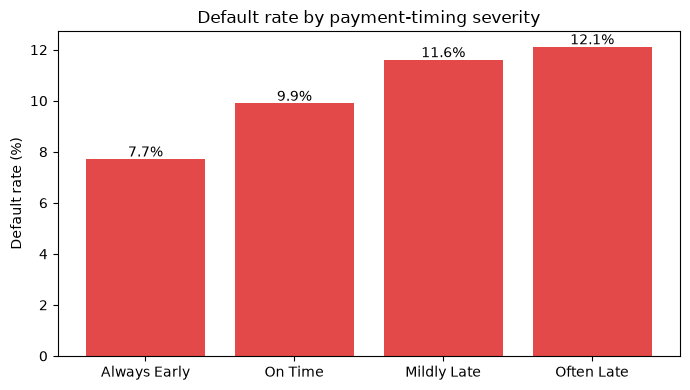

In [55]:
avg_days_late = installments.groupby('SK_ID_CURR')['DAYS_PAST_DUE'].mean()
chk = chk.drop(columns=['AVG_DAYS_PAST_DUE'], errors='ignore')
chk = chk.merge(avg_days_late.rename('AVG_DAYS_PAST_DUE'),
                left_on='SK_ID_CURR', right_index=True, how='left')

chk['LATE_SEVERITY'] = pd.cut(chk['AVG_DAYS_PAST_DUE'],
                              bins=[-9999, -5, 0, 5, 9999],
                              labels=['Always Early', 'On Time', 'Mildly Late', 'Often Late'])

sev = chk.groupby('LATE_SEVERITY', observed=True)['TARGET'].mean() * 100
print(sev)
print()
print(chk['LATE_SEVERITY'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sev.index.astype(str), sev.values, color=C_RED)
for b, v in zip(bars, sev.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.1f}%", ha='center', fontsize=10)
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate by payment-timing severity')
plt.tight_layout()
plt.savefig(FIG_PATH + "01_late_severity_gradient.png", dpi=150, bbox_inches='tight')
plt.show()

**Gradient found — with one anomaly worth checking.** Always Early (8%) →
Often Late (12%) is a clear gradient, but "On Time" (10%) sits *above*
"Always Early" (8%), which looks counterintuitive. Small-sample artifact?

In [56]:
payment_counts = installments.groupby('SK_ID_CURR').size()
chk = chk.drop(columns=['NUM_PAYMENT_RECORDS'], errors='ignore')
chk = chk.merge(payment_counts.rename('NUM_PAYMENT_RECORDS'),
                left_on='SK_ID_CURR', right_index=True, how='left')

print(chk.groupby('LATE_SEVERITY', observed=True)['NUM_PAYMENT_RECORDS'].mean())

LATE_SEVERITY
Always Early   35.54
On Time        60.43
Mildly Late    40.53
Often Late     37.37
Name: NUM_PAYMENT_RECORDS, dtype: float64


**Anomaly explained — not a data issue.** "On Time" customers have *more*
payment records (60.4 avg) than "Always Early" (35.5) — so it's not thin data.
Borrowing **volume** itself appears to correlate with risk independently of
payment timing. Decision: keep `NUM_PAYMENT_RECORDS` as its own feature
alongside the timing features — they carry distinct information.

## 5.2 Underpayment — a different behaviour from lateness

In [57]:
installments['UNDERPAID_AMOUNT'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
installments['IS_UNDERPAID'] = (installments['UNDERPAID_AMOUNT'] > 0).astype(int)

print(f"% underpaid: {installments['IS_UNDERPAID'].mean()*100:.1f}%  vs  % late: {installments['IS_PAST_DUE'].mean()*100:.1f}%")
print("\nOverlap between the two behaviours (% of all records):")
print(pd.crosstab(installments['IS_PAST_DUE'], installments['IS_UNDERPAID'], normalize='all') * 100)

% underpaid: 9.5%  vs  % late: 8.4%

Overlap between the two behaviours (% of all records):
IS_UNDERPAID     0    1
IS_PAST_DUE            
0            86.85 4.72
1             3.63 4.80


In [58]:
underpaid_customers = installments[installments['IS_UNDERPAID'] == 1]['SK_ID_CURR'].unique()
chk['HAS_UNDERPAYMENT'] = chk['SK_ID_CURR'].isin(underpaid_customers).astype(int)
print(chk.groupby('HAS_UNDERPAYMENT')['TARGET'].mean())

HAS_UNDERPAYMENT
0   0.07
1   0.10
Name: TARGET, dtype: float64


**Finding — distinct, complementary signals.** 4.7% of records are
underpaid-but-on-time, 3.6% late-but-paid-in-full, 4.8% both (likely the most
distressed segment). `HAS_UNDERPAYMENT` (10% vs 7%) is slightly stronger than
`HAS_LATE_PAYMENT`. Keep **both**.

In [59]:
installments.to_csv(DATA_PATH + "installments_cleaned.csv", index=False)
print(f"Checkpoint saved: installments_cleaned.csv  {installments.shape}")

Checkpoint saved: installments_cleaned.csv  (13605401, 12)


<a id="6"></a>
# 6. `credit_card_balance.csv` — card utilisation

Monthly statements for Home Credit's revolving products. The classic credit-risk
metric here is the **utilisation ratio** = balance / credit limit (high
utilisation = financial stress).

In [60]:
credit_card = pd.read_csv(DATA_PATH + "credit_card_balance.csv")

print(f"Shape: {credit_card.shape}")
print(f"Unique SK_ID_CURR: {credit_card['SK_ID_CURR'].nunique():,} "
      f"({credit_card['SK_ID_CURR'].nunique()/307511*100:.1f}% of app_train customers)")

Shape: (3840312, 23)
Unique SK_ID_CURR: 103,558 (33.7% of app_train customers)


## 6.1 Building the utilisation ratio — the zero-limit problem

In [61]:
zero_limit = (credit_card['AMT_CREDIT_LIMIT_ACTUAL'] == 0).sum()
print(f"Records with zero credit limit: {zero_limit:,} ({zero_limit/len(credit_card)*100:.1f}%)")
print("\nContract status of zero-limit records:")
print(credit_card[credit_card['AMT_CREDIT_LIMIT_ACTUAL'] == 0]['NAME_CONTRACT_STATUS'].value_counts())

Records with zero credit limit: 753,823 (19.6%)

Contract status of zero-limit records:
NAME_CONTRACT_STATUS
Active       700153
Completed     52837
Signed          558
Demand          275
Name: count, dtype: int64


**Finding.** 19.6% of records have a zero limit, mostly `Active` — cards
approved but not yet assigned a limit. Dividing by zero would create infinities
(nonzero balance) or NaN (zero balance); **neither 0% nor infinite utilisation
is a meaningful interpretation**.

**Decision:** compute the ratio only where the limit is positive; zero-limit
records become `NaN` (excluded from per-customer averages).

In [62]:
credit_card['UTILIZATION_RATIO'] = np.where(
    credit_card['AMT_CREDIT_LIMIT_ACTUAL'] > 0,
    credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL'],
    np.nan
)
print(credit_card['UTILIZATION_RATIO'].describe())

count   3086489.00
mean          0.37
std           0.43
min          -1.80
25%           0.00
50%           0.01
75%           0.87
max          11.78
Name: UTILIZATION_RATIO, dtype: float64


In [63]:
print(f"Negative utilization records: {(credit_card['UTILIZATION_RATIO'] < 0).sum():,}")
print(f"Over 100% utilization records: {(credit_card['UTILIZATION_RATIO'] > 1).sum():,} "
      f"({(credit_card['UTILIZATION_RATIO'] > 1).mean()*100:.1f}%)")
print(f"99th percentile: {credit_card['UTILIZATION_RATIO'].quantile(0.99):.2f}")

Negative utilization records: 2,331
Over 100% utilization records: 334,362 (8.7%)
99th percentile: 1.07


**Extremes are mostly real behaviour.** 10.8% of records exceed 100%
utilisation — normal for credit cards (interest/fees push balances over the
limit), and genuinely a stress signal worth *preserving*. The 99th percentile
is only 1.07, so extreme values beyond that are rare.

**Decision:** clip negatives (overpayment adjustments) to 0; winsorise the top
at the 99th percentile (1.07). Over-limit signal between 1.0 and 1.07 is kept.

In [64]:
credit_card['UTILIZATION_RATIO'] = credit_card['UTILIZATION_RATIO'].clip(
    lower=0, upper=credit_card['UTILIZATION_RATIO'].quantile(0.99))
print(credit_card['UTILIZATION_RATIO'].describe())

count   3086489.00
mean          0.37
std           0.43
min           0.00
25%           0.00
50%           0.01
75%           0.87
max           1.07
Name: UTILIZATION_RATIO, dtype: float64


## 6.2 Does utilisation predict default? (MEAN aggregation)

UTIL_BUCKET
Very Low     5.44
Low          6.94
Medium       8.86
High        13.04
Very High   19.25
Name: TARGET, dtype: float64

UTIL_BUCKET
Very Low     33580
Medium       18838
High         15903
Low          12578
Very High     5137
Name: count, dtype: int64


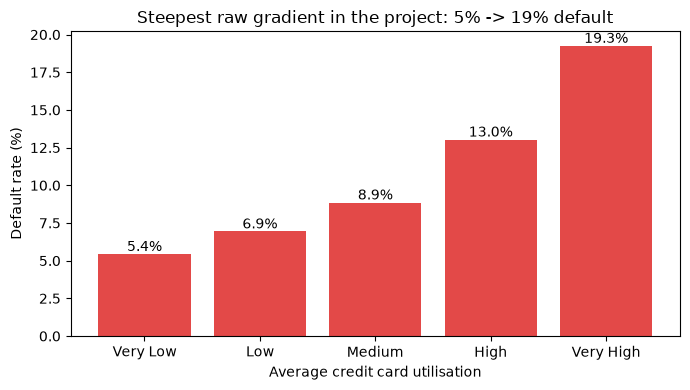

In [65]:
avg_utilization = credit_card.groupby('SK_ID_CURR')['UTILIZATION_RATIO'].mean()
chk = chk.drop(columns=['AVG_UTILIZATION'], errors='ignore')
chk = chk.merge(avg_utilization.rename('AVG_UTILIZATION'),
                left_on='SK_ID_CURR', right_index=True, how='left')

chk['UTIL_BUCKET'] = pd.cut(chk['AVG_UTILIZATION'],
                            bins=[-0.01, 0.1, 0.3, 0.6, 0.9, 1.1],
                            labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

util = chk.groupby('UTIL_BUCKET', observed=True)['TARGET'].mean() * 100
print(util)
print()
print(chk['UTIL_BUCKET'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(util.index.astype(str), util.values, color=C_RED)
for b, v in zip(bars, util.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v:.1f}%", ha='center', fontsize=10)
ax.set_ylabel('Default rate (%)')
ax.set_xlabel('Average credit card utilisation')
ax.set_title('Steepest raw gradient in the project: 5% -> 19% default')
plt.tight_layout()
plt.savefig(FIG_PATH + "01_utilization_gradient.png", dpi=150, bbox_inches='tight')
plt.show()

**Key finding — the strongest raw signal in the whole EDA.** A clean,
monotonic ~4x spread (5% → 19%) across utilisation buckets. `AVG_UTILIZATION`
becomes a priority feature, expected to rank alongside the EXT_SOURCE scores.

## 6.3 MEAN vs MAX — which aggregation captures the signal?

In [66]:
max_utilization = credit_card.groupby('SK_ID_CURR')['UTILIZATION_RATIO'].max()
chk = chk.drop(columns=['MAX_UTILIZATION'], errors='ignore')
chk = chk.merge(max_utilization.rename('MAX_UTILIZATION'),
                left_on='SK_ID_CURR', right_index=True, how='left')

chk['MAX_UTIL_BUCKET'] = pd.cut(chk['MAX_UTILIZATION'],
                                bins=[-0.01, 0.1, 0.3, 0.6, 0.9, 1.1],
                                labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

print("MAX-based buckets:")
print(chk.groupby('MAX_UTIL_BUCKET', observed=True)['TARGET'].mean() * 100)
print()
print(chk['MAX_UTIL_BUCKET'].value_counts())

MAX-based buckets:
MAX_UTIL_BUCKET
Very Low     5.46
Low          5.35
Medium       5.74
High         7.09
Very High   11.22
Name: TARGET, dtype: float64

MAX_UTIL_BUCKET
Very High    45685
Very Low     28331
High          5810
Medium        3743
Low           2467
Name: count, dtype: int64


**Key finding — MEAN wins, and the reason generalises.** MEAN's 4x spread
beats MAX's 2x. Occasional utilisation *spikes* are normal card behaviour
(45,685 customers hit "Very High" at least once — too common to discriminate);
**sustained** high utilisation is what signals genuine stress.

Note this is the **opposite** of the bureau-overdue result, where MAX beat
MEAN. The general rule discovered:

> **Rare/abnormal events → MAX. Common/continuous behaviour → MEAN.**

This rule drives the choice of SQL aggregate function per table in notebook 02.

In [67]:
credit_card.to_csv(DATA_PATH + "credit_card_cleaned.csv", index=False)
print(f"Checkpoint saved: credit_card_cleaned.csv  {credit_card.shape}")

Checkpoint saved: credit_card_cleaned.csv  (3840312, 24)


<a id="7"></a>
# 7. `POS_CASH_balance.csv` — POS/cash loan snapshots

Monthly snapshots for non-revolving loans; `SK_DPD` = days past due that month.

In [68]:
pos_cash = pd.read_csv(DATA_PATH + "POS_CASH_balance.csv")

print(f"Shape: {pos_cash.shape}")
print(f"Unique SK_ID_CURR: {pos_cash['SK_ID_CURR'].nunique():,}")
print(f"\nRecords with any overdue (SK_DPD > 0): {(pos_cash['SK_DPD'] > 0).sum():,} "
      f"({(pos_cash['SK_DPD'] > 0).mean()*100:.2f}%)")

Shape: (10001358, 8)
Unique SK_ID_CURR: 337,252

Records with any overdue (SK_DPD > 0): 295,227 (2.95%)


Only 2.95% of records show overdue days — a **rare event**, so by the rule
from section 6.3: aggregate with **MAX**.

In [69]:
max_dpd = pos_cash.groupby('SK_ID_CURR')['SK_DPD'].max()
chk = chk.drop(columns=['MAX_POS_DPD'], errors='ignore')
chk = chk.merge(max_dpd.rename('MAX_POS_DPD'), left_on='SK_ID_CURR', right_index=True, how='left')

chk['POS_DPD_FLAG'] = (chk['MAX_POS_DPD'] > 0).astype(int)
print(chk.groupby('POS_DPD_FLAG')['TARGET'].mean())
print()
print(chk['POS_DPD_FLAG'].value_counts())

POS_DPD_FLAG
0   0.08
1   0.10
Name: TARGET, dtype: float64

POS_DPD_FLAG
0    252828
1     54683
Name: count, dtype: int64


**Finding — moderate signal.** 10% vs 8% (2pp gap) with a solid sample
(54,683 customers). Weaker than bureau's equivalent but worth keeping as a
supplementary feature. `NAME_CONTRACT_STATUS` here is 91.5% "Active" — too
dominated by one category to be useful on its own; not pursued.

In [70]:
pos_cash.to_csv(DATA_PATH + "pos_cash_cleaned.csv", index=False)
print(f"Checkpoint saved: pos_cash_cleaned.csv  {pos_cash.shape}")

Checkpoint saved: pos_cash_cleaned.csv  (10001358, 8)


<a id="8"></a>
# 8. Summary — what this EDA found and decided

## 8.1 All discovered flags, side by side

                 feature  default_rate_flag0  default_rate_flag1  spread_x
7  DAYS_EMPLOYED_ANOMALY                8.66                5.40      0.62
3       HAS_LATE_PAYMENT                6.72                9.41      1.40
2       HAS_UNDERPAYMENT                7.01                9.63      1.37
4           POS_DPD_FLAG                7.64               10.06      1.32
1      HAS_PRIOR_REFUSAL                6.98               10.32      1.48
6     HAS_SEVERE_OVERDUE                8.05               11.02      1.37
0    HAS_OVERDUE_HISTORY                7.99               15.90      1.99
5           HAS_BAD_DEBT                8.07               20.00      2.48


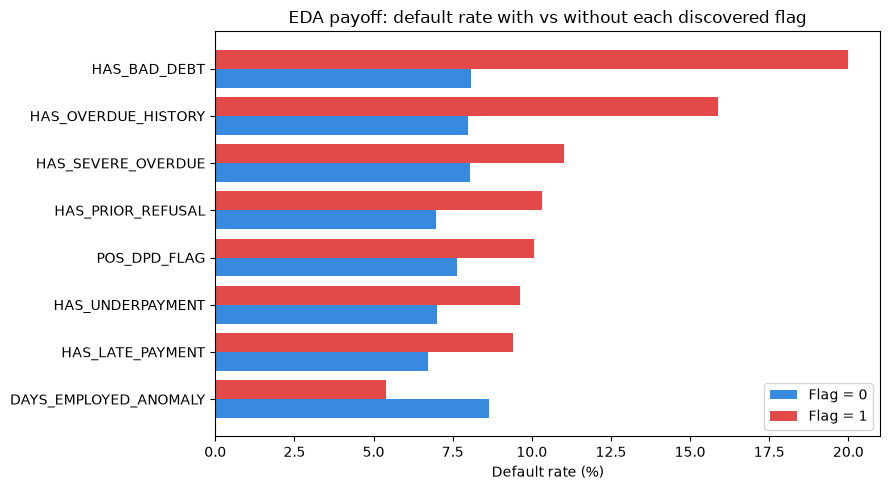

In [71]:
summary_flags = ['HAS_OVERDUE_HISTORY', 'HAS_PRIOR_REFUSAL', 'HAS_UNDERPAYMENT',
                 'HAS_LATE_PAYMENT', 'POS_DPD_FLAG', 'HAS_BAD_DEBT',
                 'HAS_SEVERE_OVERDUE', 'DAYS_EMPLOYED_ANOMALY']

rows = []
for flag in summary_flags:
    rates = chk.groupby(flag)['TARGET'].mean() * 100
    if 0 in rates.index and 1 in rates.index:
        rows.append({'feature': flag, 'default_rate_flag0': rates[0],
                     'default_rate_flag1': rates[1],
                     'spread_x': rates[1] / rates[0]})

flag_df = pd.DataFrame(rows).sort_values('default_rate_flag1')
print(flag_df.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(flag_df))
ax.barh(y - 0.2, flag_df['default_rate_flag0'], height=0.4, color=C_BLUE, label='Flag = 0')
ax.barh(y + 0.2, flag_df['default_rate_flag1'], height=0.4, color=C_RED, label='Flag = 1')
ax.set_yticks(y)
ax.set_yticklabels(flag_df['feature'])
ax.set_xlabel('Default rate (%)')
ax.set_title('EDA payoff: default rate with vs without each discovered flag')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH + "01_flag_summary.png", dpi=150, bbox_inches='tight')
plt.show()

## 8.2 Ranked candidate features (input to Stages 1 & 4)

| # | Candidate | Evidence found here | Strength |
|---|---|---|---|
| 1 | `AVG_UTILIZATION` (credit card) | 5% → 19% default across buckets, monotonic | Steepest raw gradient in project |
| 2 | `EXT_SOURCE_1/2/3` | corr −0.16 to −0.18; shifted distributions | Strongest individual columns |
| 3 | `HAS_OVERDUE_HISTORY` (bureau) | 16% vs 8% (2.0x), n=3,397 | Strong + reliable |
| 4 | `NAME_EDUCATION_TYPE` | clean monotonic 2%→11% gradient | Strong categorical |
| 5 | `HAS_PRIOR_REFUSAL` | 10% vs 7%, n=100k | Reliable, large sample |
| 6 | `HAS_UNDERPAYMENT` | 10% vs 7% | Moderate |
| 7 | `AVG_DAYS_PAST_DUE` / severity | 8%→12% gradient | Moderate, better than binary flag |
| 8 | `POS_DPD_FLAG` | 10% vs 8% | Moderate |
| 9 | `NUM_PAYMENT_RECORDS` | volume-risk link found via "On Time" anomaly | Moderate, independent info |
| 10 | `HAS_BUREAU_HISTORY` | 10% vs 8% (thin-file signal) | Weak but real |
| 11 | `DAYS_EMPLOYED_ANOMALY` | corr ~0.05; ties to OCCUPATION_TYPE missingness | Weak but real |
| 12 | `HAS_BUILDING_INFO` | ~2pp gap, replaces 45 sparse columns | Weak but cheap |
| 13 | `HAS_LATE_PAYMENT` | 9% vs 7% — too common to discriminate | Weak; needs refinement in Stage 4 |
| 14 | `HAS_BAD_DEBT` / `HAS_SEVERE_OVERDUE` | logical direction, tiny samples | Weakest; kept at low cost |

## 8.3 Cleaning decisions (all applied to the saved checkpoints)

| Table | Decision |
|---|---|
| app_train | `DAYS_EMPLOYED` sentinel (365243) → NaN, with anomaly flag created first |
| app_train | `AMT_INCOME_TOTAL` winsorised at 99th pct (247x gap ratio = data error) + outlier flag |
| app_train | 4 building categoricals + 44 building numerics → single `HAS_BUILDING_INFO` flag |
| app_train | 20 near-constant / zero-signal FLAG columns dropped; `FLAG_OWN_REALTY` dropped |
| app_train | `ORGANIZATION_TYPE` 58 → 25 categories (min-count 2000); `CNT_CHILDREN` capped at 5 |
| bureau | negative debt clipped to 0; `AMT_CREDIT_SUM(_DEBT)` winsorised at 99th pct |
| bureau_balance | **excluded from pipeline** — 27.3M rows for a 3pp signal |
| previous_application | no capping needed; Approved vs Refused aggregated separately (structural missingness) |
| credit_card | utilisation ratio built with zero-limit → NaN; clipped to [0, 99th pct] |
| all remaining missingness | deferred to Stage 6 model pipelines (fit on train only — no leakage) |

## 8.4 The aggregation rule that drives notebook 02

> **Rare / abnormal events → `MAX`** (bureau overdue, POS DPD, bad debt)
> **Common / continuous behaviour → `MEAN`** (utilisation, days past due)
> **Total exposure → `SUM`/`COUNT`** (debt amounts, loan counts)
> **Structurally missing subsets → conditional `CASE WHEN`** (Approved vs Refused)

## Next: Notebook 02 — SQL pipeline
Collapse each child table to one row per customer using these rules, re-verify
every aggregate against the exact default rates found here, and LEFT JOIN
everything onto `app_train_cleaned` → one flat modelling table.